In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import NMF, PCA, TruncatedSVD
import utils
from clean import load_clean, answer_text

fig_dir = "../report/figs/"

clean_df, X, questions = load_clean()
states = utils.load_states()
print(X.shape)

(45436, 468)


### PCA on X, centered, not scaled

The matrix X is representing the answer that each participant gave to all the questions and is thus on the same scale for everyone. In fact, scaling (e.g. by dividing by SD) would weigh rare answers more, which is not what we want for this analysis.

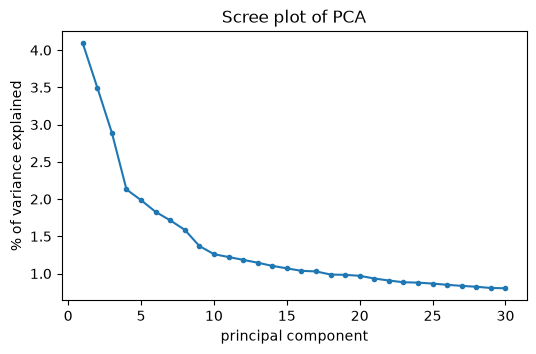

first 4 PCs together: 13%


In [10]:
pca = PCA(n_components=30, random_state=42).fit(X)
scores = pca.transform(X)
percent_variance = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(range(1, 31), percent_variance, "o-", markersize=3)
ax.set_xlabel("principal component")
ax.set_ylabel("% of variance explained")
ax.set_title("Scree plot of PCA")
fig.savefig(fig_dir + "dimred-scree.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"first 4 PCs together: {percent_variance[:4].sum():.0f}%")

It seems like there is a bit of a steep slope that then changes a bit at 4 PCs.

### Top 4 PCs

Let's take a look at what these 4 PCs are

In [3]:
def answer_name(column):
    '''"Q105_2" -> "Q105 <question text>", then the answer ("pop") on the next line'''
    q, code = column.split("_")
    return q + " " + questions[q]["question"] + "\n " + answer_text(questions, q, int(code)) +"\n"

def top_answers(components, k, n=4):
    loadings = pd.Series(components[k], index=X.columns).sort_values()
    print(f"PC{k + 1}")
    print("  negative:", "\n  ".join(answer_name(c) for c in loadings.index[:n]))
    print("  positive:", "\n  ".join(answer_name(c) for c in loadings.index[::-1][:n]))

for k in range(4):
    top_answers(pca.components_, k)

PC1
  negative: Q073 What is your *general* term for the rubber-soled shoes worn in gym class, for athletic activities, etc.?
 tennis shoes

  Q080 What do you call it when rain falls while the sun is shining?
 I have no term or expression for this

  Q105 What is your generic term for a sweetened carbonated beverage?
 pop

  Q106 What do you call the act of covering a house or area in front of a house with toilet paper?
 tp'ing

  positive: Q073 What is your *general* term for the rubber-soled shoes worn in gym class, for athletic activities, etc.?
 sneakers

  Q105 What is your generic term for a sweetened carbonated beverage?
 soda

  Q080 What do you call it when rain falls while the sun is shining?
 sunshower

  Q056 Pantyhose are so expensive anymore that I just try to get a good suntan and forget about it.
 unacceptable

PC2
  negative: Q076 What term do you use to refer to something that is across both streets from you at an intersection (or diagonally across from you in genera

PC1 seems to show the soda/sneakers vs pop/tennis shoes divide. PC2 also has catty-corner/kitty-corner and water foundain/drinking fountain divide. Perhaps both PC1 and PC2 have a regional compnent to it.

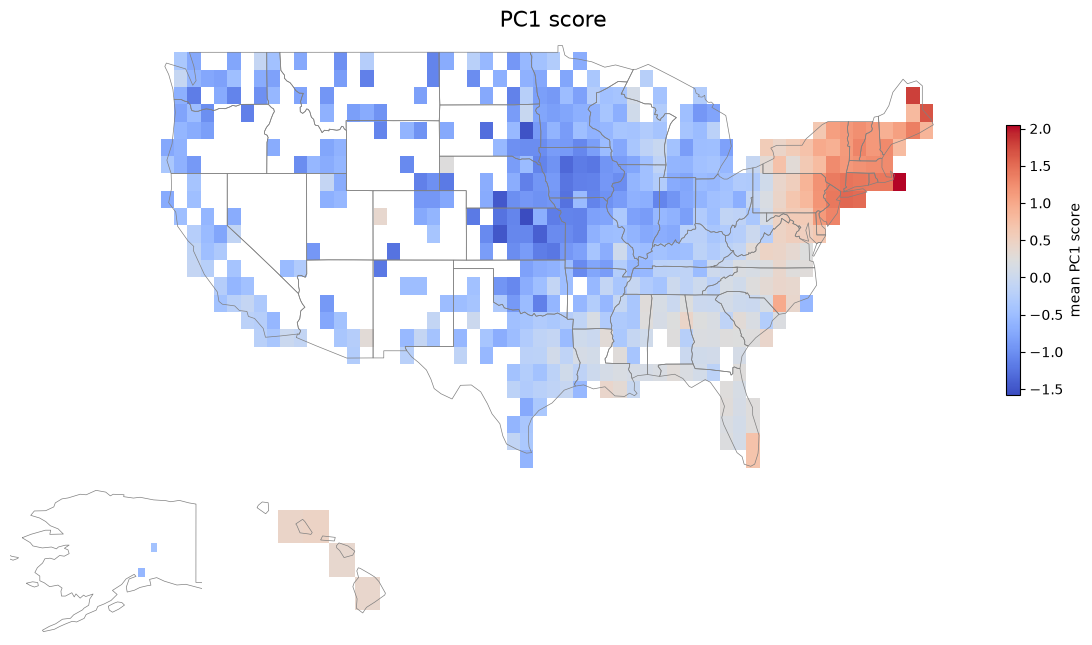

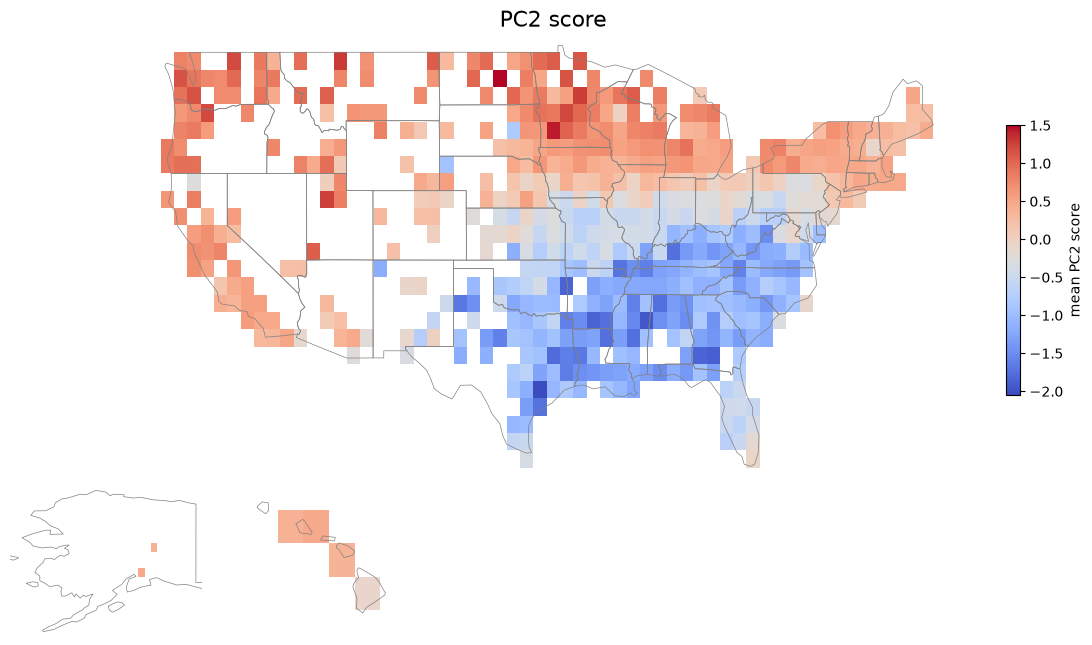

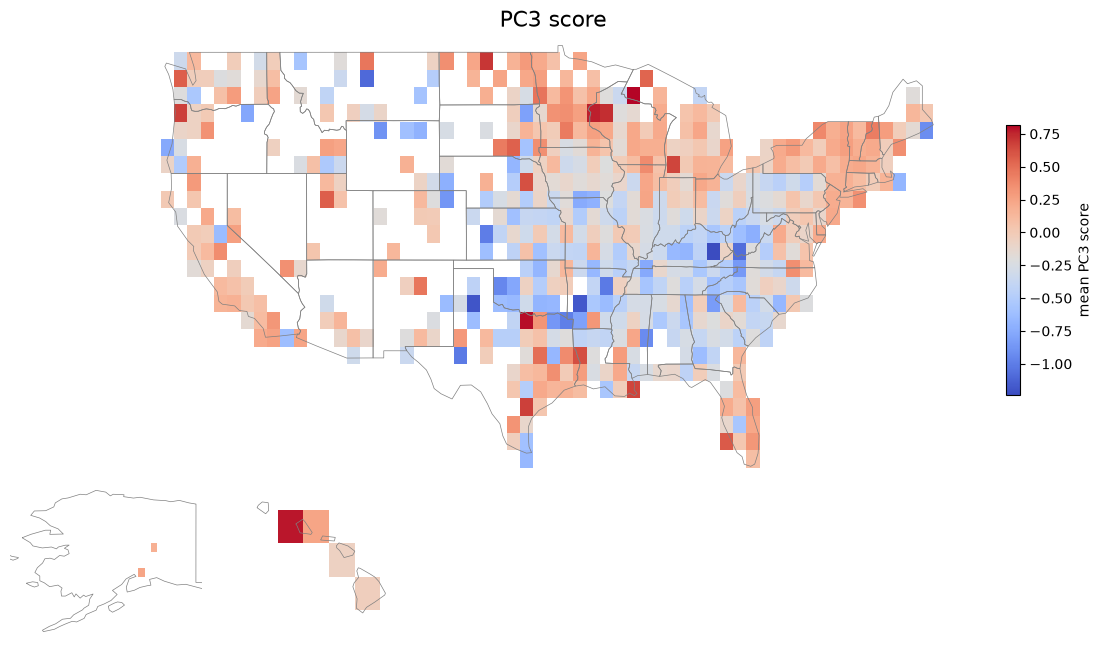

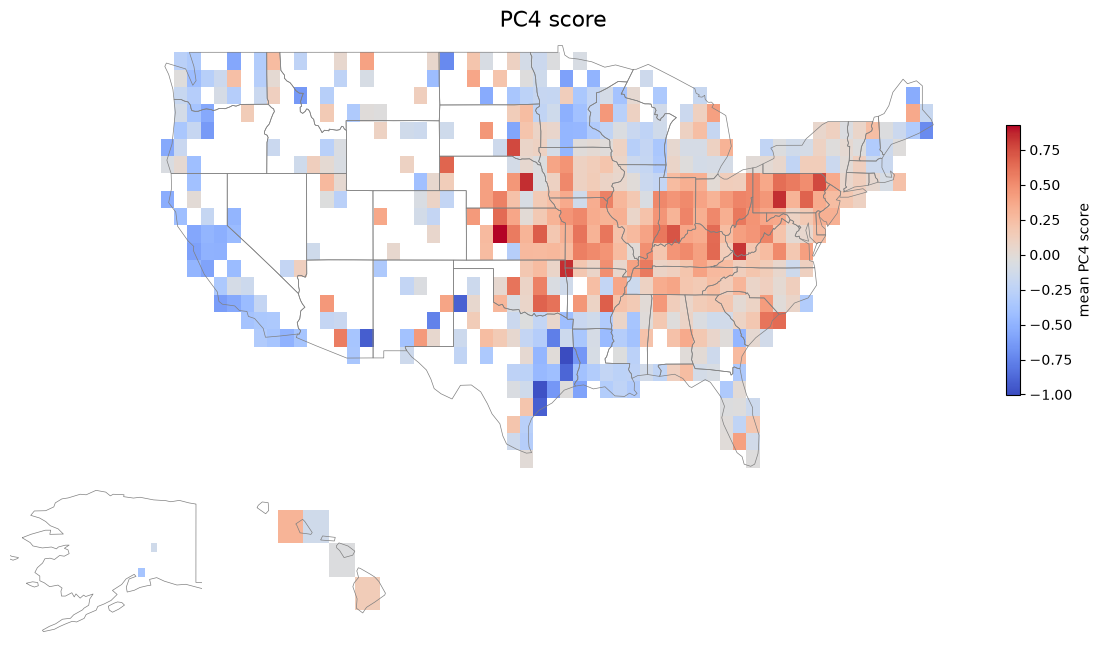

In [11]:
for k in range(4):
    fig, axes = utils.map_values(clean_df, scores[:, k], states, cmap="coolwarm",
                                 label=f"mean PC{k + 1} score")
    axes["contiguous"].set_title(f"PC{k + 1} score", fontsize=16)
    fig.savefig(fig_dir + f"dimred-map-PC{k + 1}.png", dpi=150, bbox_inches="tight")
    plt.show()

PC1 and PC2 seem to show a clear regional pattern with the loadings. PC3 seems to be more distributed across the map and PC4 might show a bit of a regional pattern in the middle of the map, but does not seem to align with traditional notions of how the map is grouped.

### Centering and scaling

Let's try to see if centering and scaling change the results. 

- uncentered: Run TruncatedSVD so X is not centered
- standardized: Divide X by SD before running PCA

Plot the top 4 PC scores again

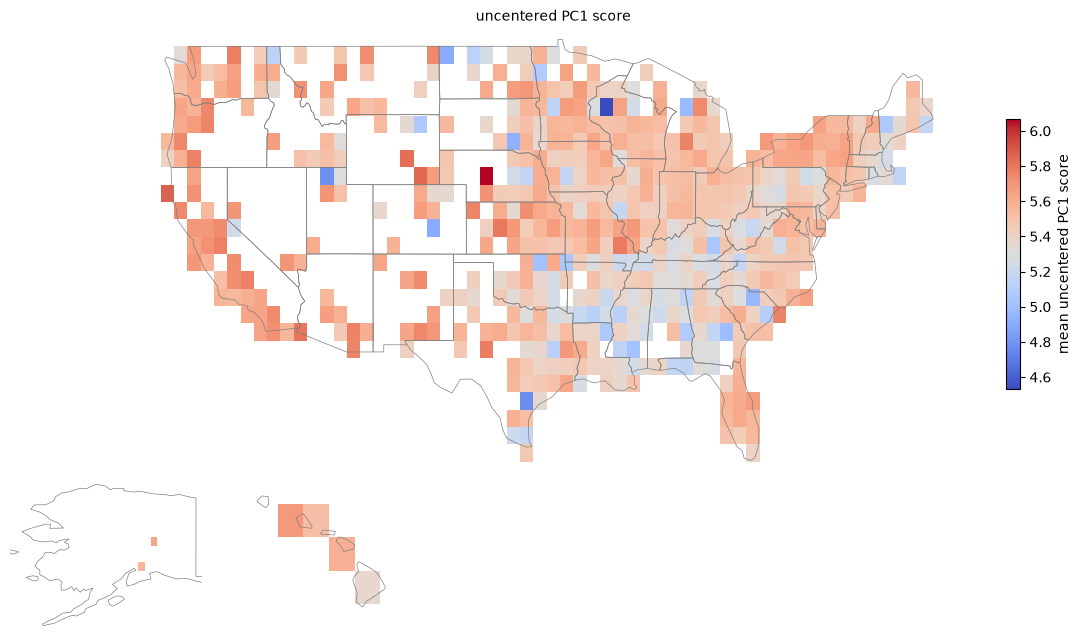

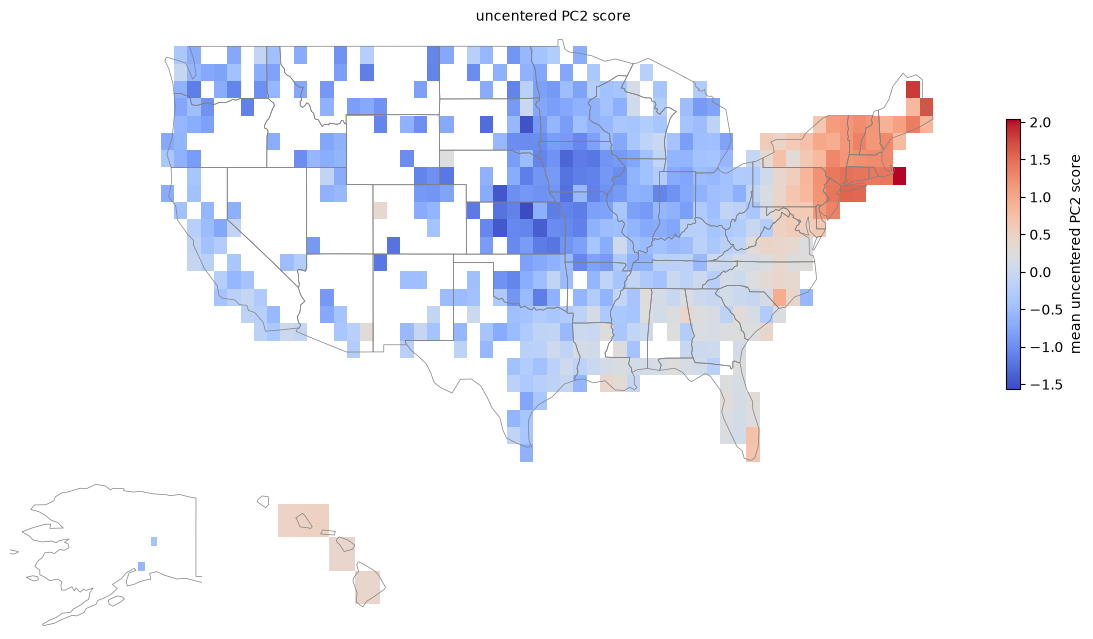

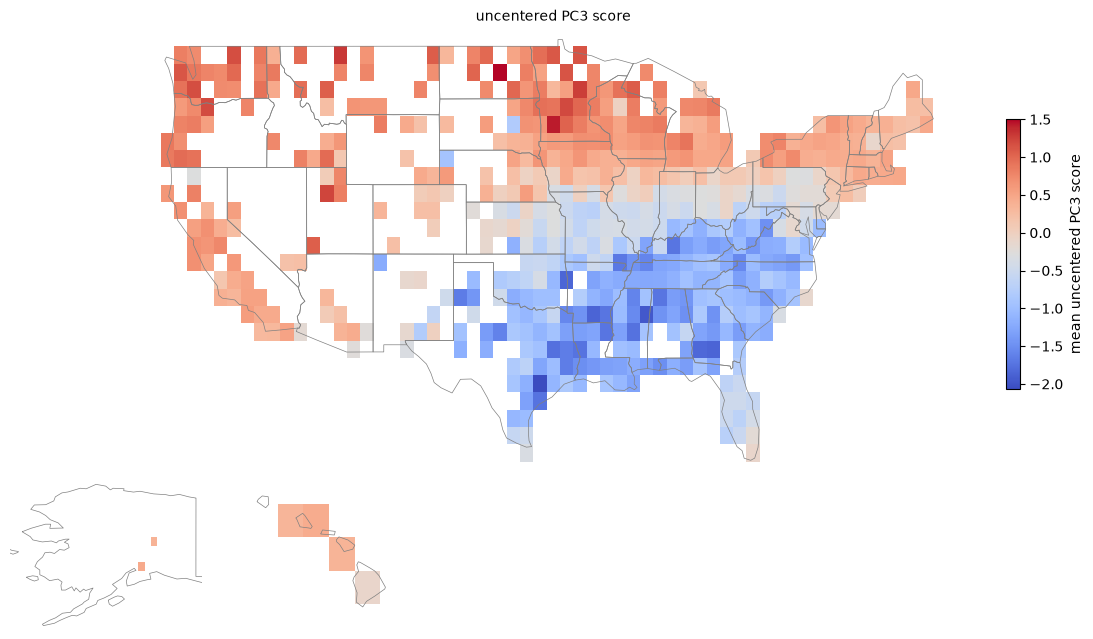

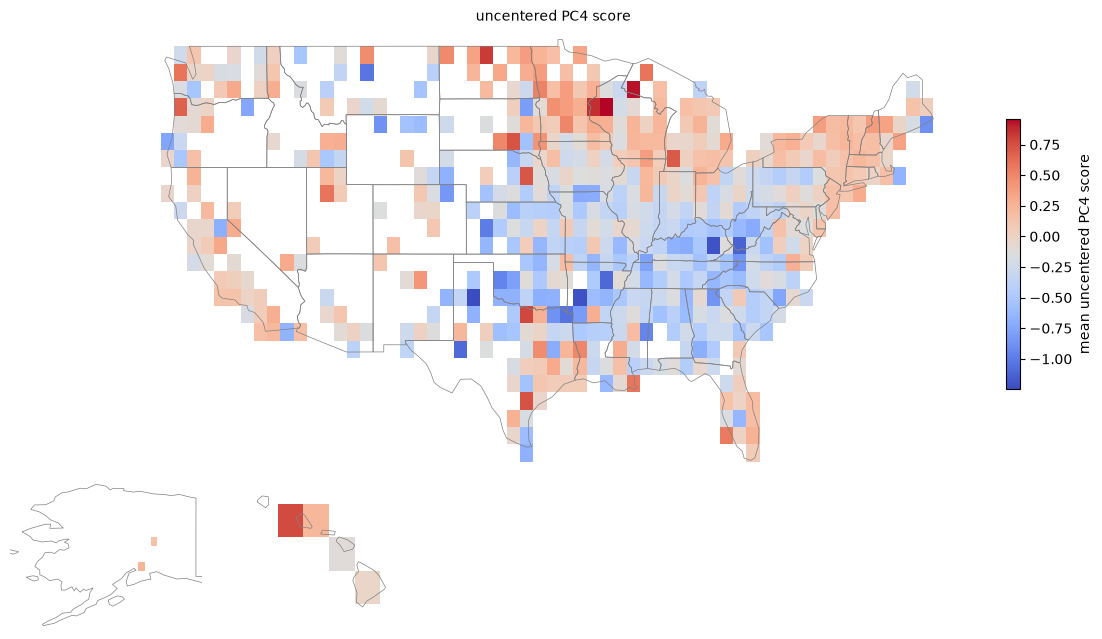

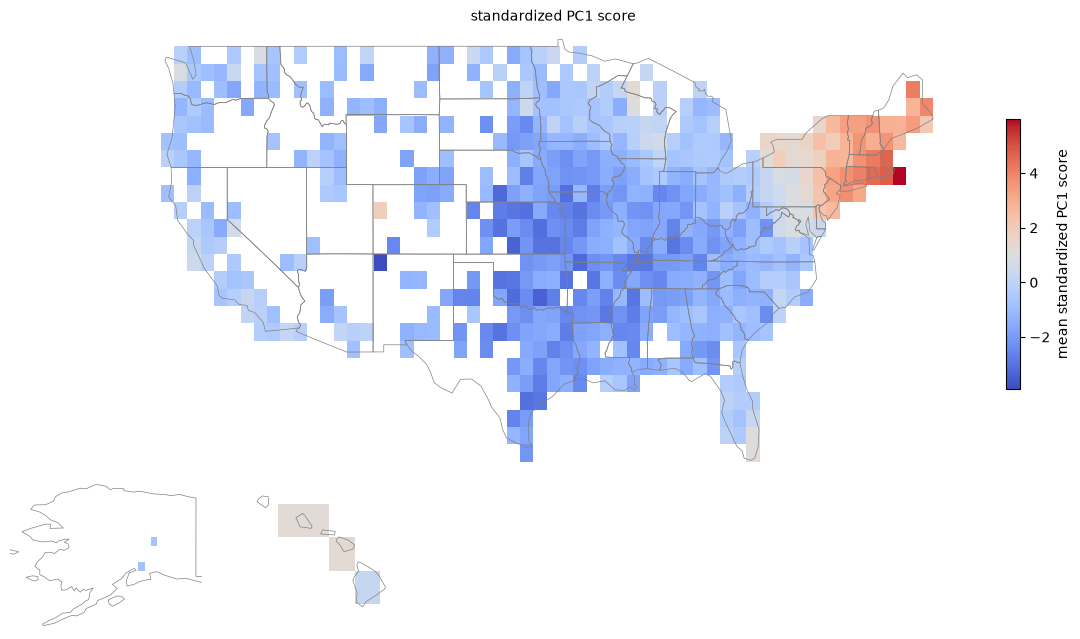

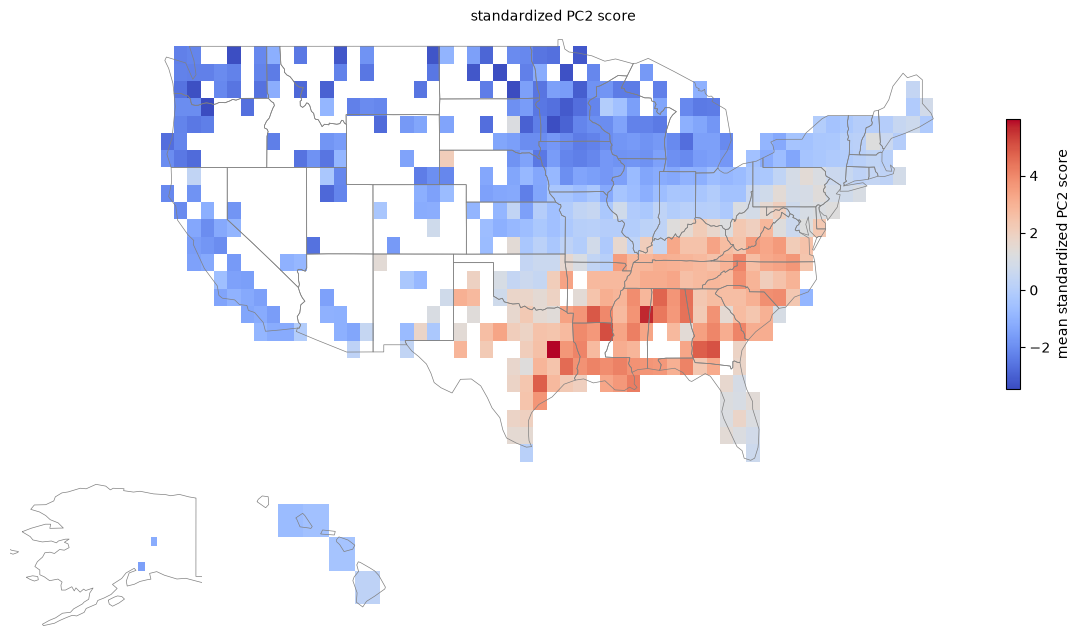

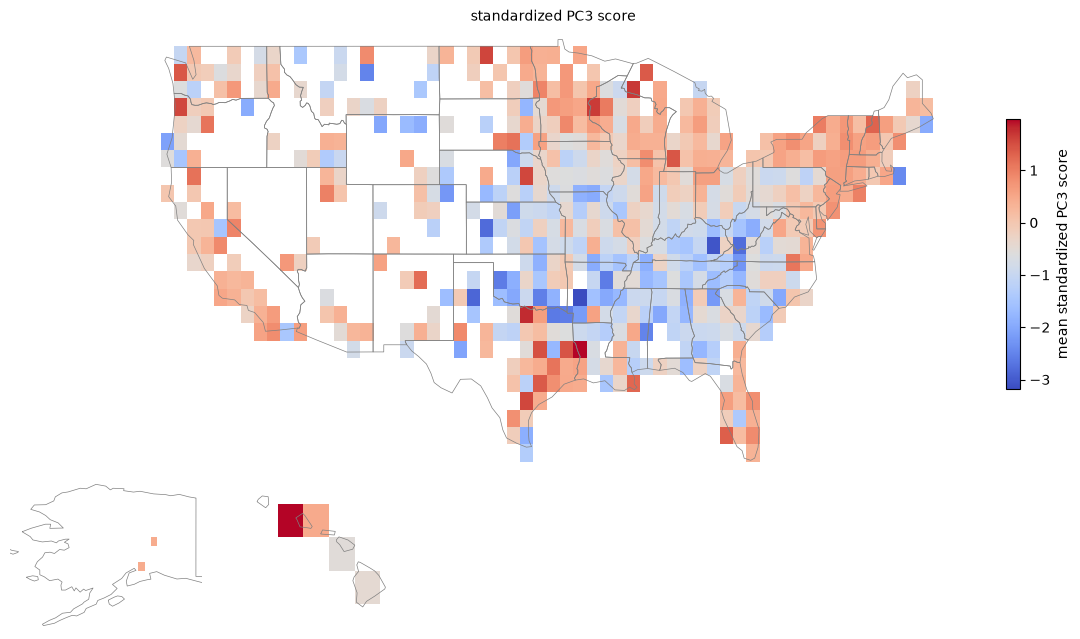

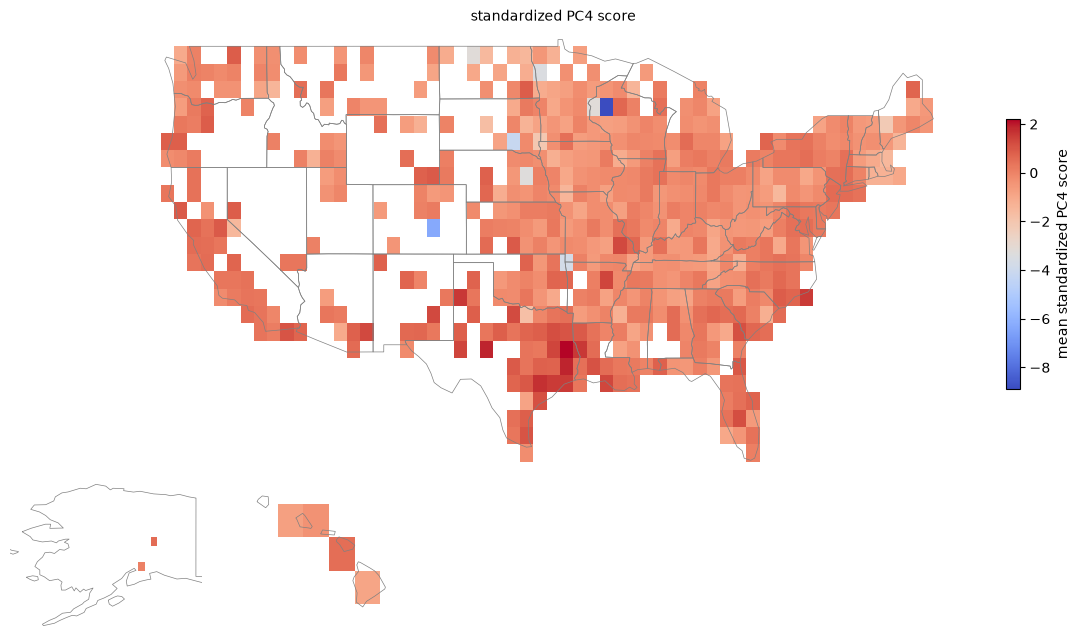

In [5]:
uncentered_scores = TruncatedSVD(n_components=4, random_state=42).fit_transform(X.values)
standardized_scores = PCA(n_components=4, random_state=42).fit_transform((X / X.std()).values)

for name, version_scores in [("uncentered", uncentered_scores), ("standardized", standardized_scores)]:
    for k in range(4):
        fig, axes = utils.map_values(clean_df, version_scores[:, k], states, cmap="coolwarm",
                                     label=f"mean {name} PC{k + 1} score")
        axes["contiguous"].set_title(f"{name} PC{k + 1} score", fontsize=10)
        fig.savefig(fig_dir + f"dimred-map-{name}-PC{k + 1}.png", dpi=150, bbox_inches="tight")
        plt.show()

Uncentered basically looks like the first PC is showing the average values and the other PCs follow. Standardized looks similar except for PC4. I think this is showing one of the cases where the negative answers are rare, which is weighted more when standardized.

### NMF

X has no negative values, so we can try to use NMF to find the solution that would describe each person as a weighted sum of k nonnegative profiles.

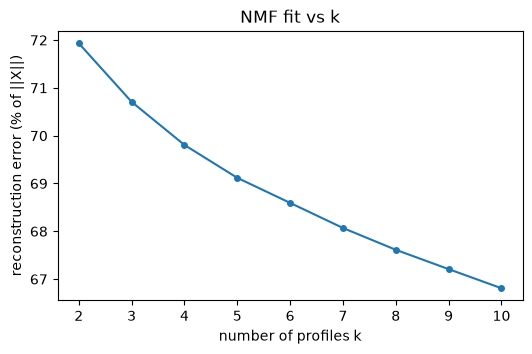

In [6]:
errors = {}
for k in range(2, 11):
    model = NMF(n_components=k, max_iter=2000, random_state=42).fit(X.values)
    errors[k] = model.reconstruction_err_ / np.linalg.norm(X.values) * 100

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(list(errors), list(errors.values()), "o-", markersize=4)
ax.set_xlabel("number of profiles k")
ax.set_ylabel("reconstruction error (% of ||X||)")
ax.set_title("NMF fit vs k")
fig.savefig(fig_dir + "dimred-nmf-error.png", dpi=150, bbox_inches="tight")
plt.show()

The number of profiles seem to steadily improve the fit. Let's use k = 4 to match the 4 PCs.

In [7]:
nmf = NMF(n_components=4, max_iter=2000, random_state=42)
W = nmf.fit_transform(X.values)
H = pd.DataFrame(nmf.components_, columns=X.columns)

answer_share = H / H.sum(axis=0)
common = X.mean() >= 0.01
for c in range(4):
    top = answer_share.loc[c, common].sort_values(ascending=False).index[:4]
    print(f"profile {c + 1}:")
    print("  " + "\n  ".join(answer_name(a) for a in top))

profile 1:
  Q077 What do you call the activity of driving around in circles in a car?
 whipping shitties

  Q073 What is your *general* term for the rubber-soled shoes worn in gym class, for athletic activities, etc.?
 shoes

  Q051 Would you say 'Are you coming with?' as a full sentence, to mean 'Are you coming with us?'
 yes

  Q107 What do you call a traffic jam caused by drivers slowing down to look at an accident or other diversion on the side of the road?
 I have no word for this

profile 2:
  Q064 What do you call the long sandwich that contains cold cuts, lettuce, and so on?
 hero

  Q093 When you stand outside with a long line of people waiting to get in somewhere, are you standing 'in line' or 'on line' (as in, 'I stood ___ in the cold for two hours before they opened the doors')?
 on line

  Q063 What do you call the drink made with milk and ice cream?
 frappe

  Q106 What do you call the act of covering a house or area in front of a house with toilet paper?
 I have no word

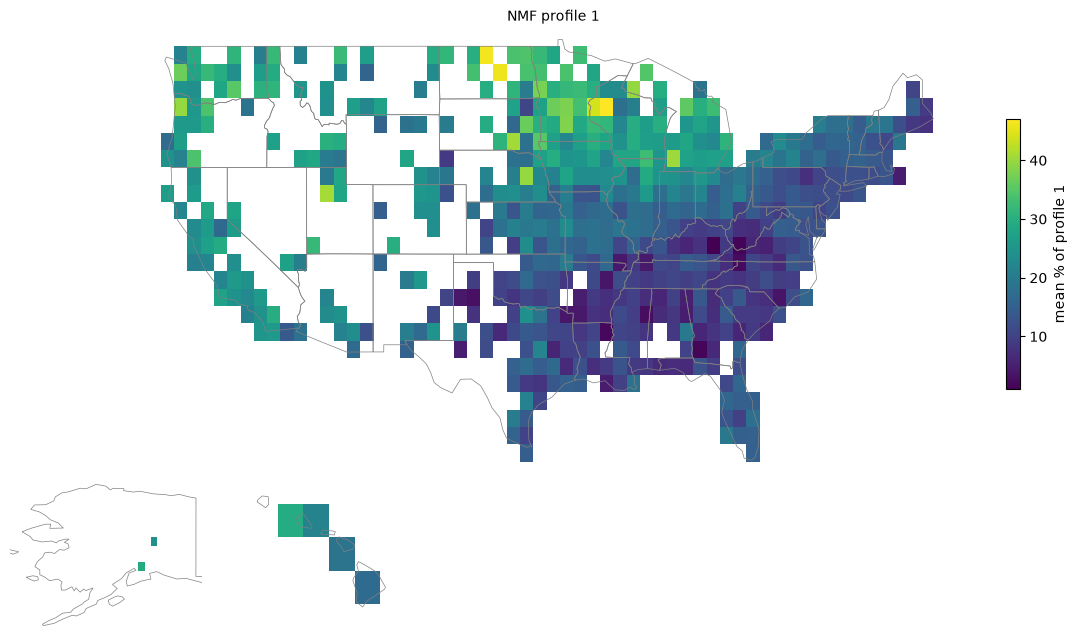

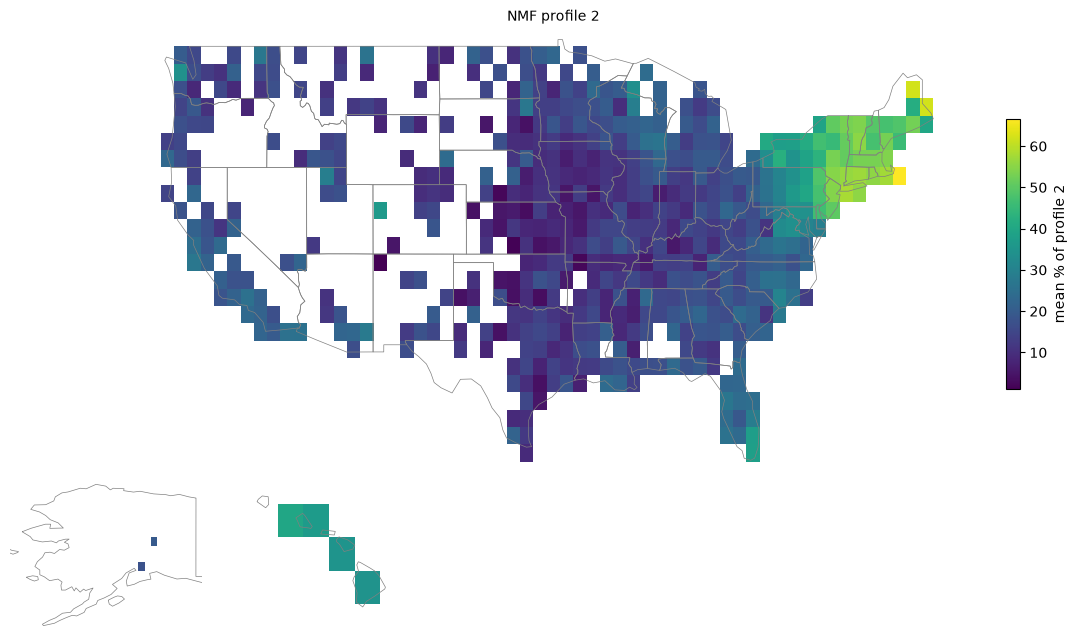

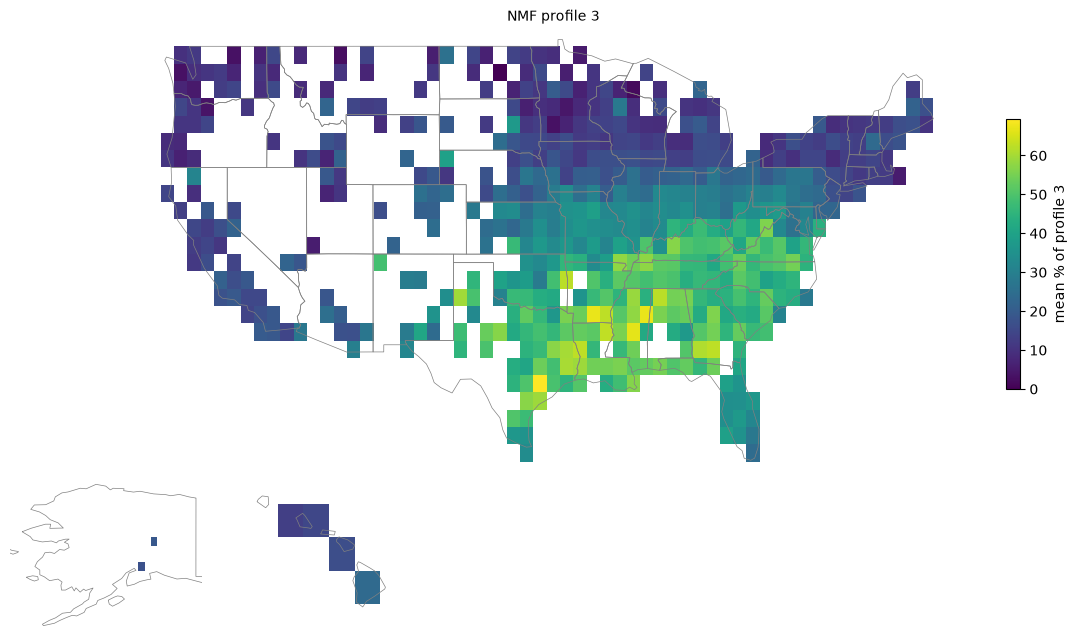

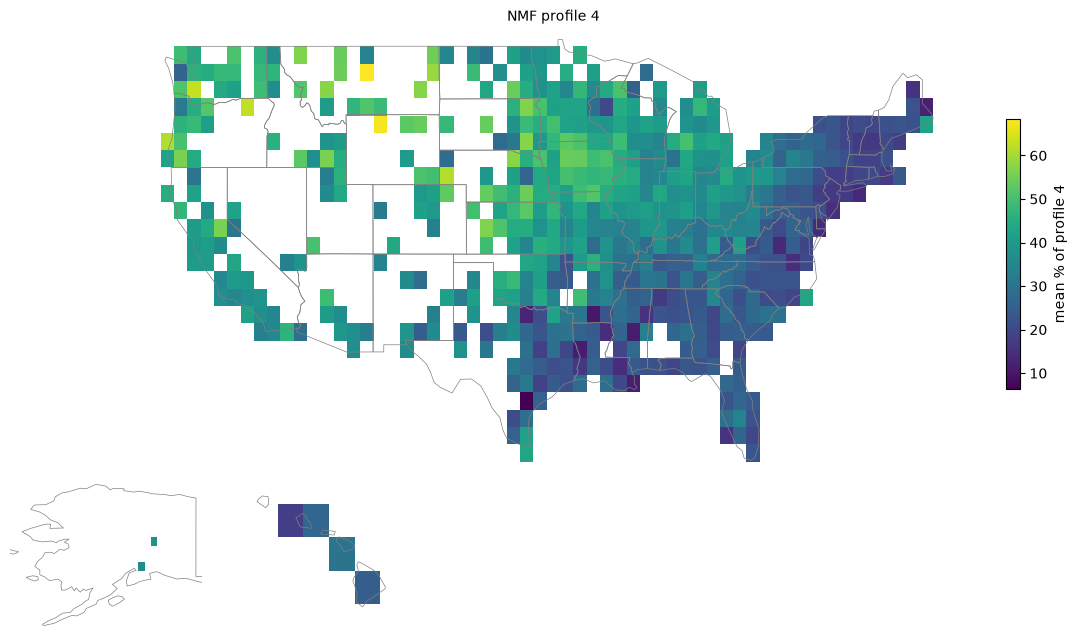

In [8]:
profile_percent = W / W.sum(axis=1, keepdims=True) * 100

for c in range(4):
    fig, axes = utils.map_values(clean_df, profile_percent[:, c], states, cmap="viridis",
                                 label=f"mean % of profile {c + 1}")
    axes["contiguous"].set_title(f"NMF profile {c + 1}", fontsize=10)
    fig.savefig(fig_dir + f"dimred-nmf-map-{c + 1}.png", dpi=150, bbox_inches="tight")
    plt.show()

These NMF profiles show clear regional patterns. Since these are non-negative matrices, we could also think of them as being additive to reach the full dataset. Some of these profiles show more sharp or gradual patterns of language usage across the map. However, the exact profile depends on the k value and random seed for starting point.

PCA provides a picture of contrast on the axes with the largest variance whereas NMF gives a separate profile for each region. Both methods seem to find patterns in similar regions of the US.